In [99]:
#Basic libraries 
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# SkLearn - we will use step by step
from sklearn.model_selection import train_test_split

In [100]:
# step 2:load and merge dataset
# load datasets
train_df=pd.read_csv(r"C:\Users\singireddyUdayasri\Downloads\archive (22)\train.csv")
test_df=pd.read_csv(r"C:\Users\singireddyUdayasri\Downloads\archive (22)\test.csv")


In [101]:
# check first few rows
print(train_df.head())
print(train_df.shape)

   id                 date region       channel product_category  \
0   1  2011-12-05 11:31:00   Nort        Search          General   
1   2  2011-04-27 14:01:00  North  Social Media          General   
2   3  2010-11-09 15:20:00  North     Affiliate          General   
3   4  2010-10-03 15:24:00  North     Affiliate          Storage   
4   5  2011-10-14 09:28:00  North        Search         Lighting   

  customer_segment  ad_spend  price  discount_rate  market_reach  impressions  \
0         Standard      9.00   0.75         0.2782          32.0          817   
1          Premium      3.35   3.35         0.0912          61.0         2289   
2           Budget      2.55   2.55         0.1997         461.0        14697   
3          Premium      2.95   2.95         0.4767         744.0        17578   
4          Premium     15.00   1.25         0.3536         226.0         6280   

   click_through_rate  competition_index  seasonality_index  \
0              0.0010               3.34 

In [102]:
print(test_df.head())
print(test_df.shape)

      id                 date  region       channel product_category  \
0  18001  2010-11-14 13:39:00   North  Social Media          Storage   
1  18002  2010-10-10 11:53:00   North     Affiliate          Storage   
2  18003  2010-10-31 11:06:00   North  Social Media          General   
3  18004  2011-02-07 14:51:00   South  Social Media          General   
4  18005  2011-05-16 14:24:00  north         Search          General   

  customer_segment  ad_spend  price  discount_rate  market_reach  impressions  \
0          Premium     16.50   1.65         0.2763         845.0        16185   
1          Premium     15.00   1.25         0.1694         525.0         5684   
2          Premium    325.44   3.39         0.3736         362.0        11490   
3          Premium      7.80   0.65         0.3246         138.0         3046   
4          Premium    458.00   4.58         0.2625         309.0         8983   

   click_through_rate  competition_index  seasonality_index  \
0              0.

In [103]:
# add target column to test manually
test_df["Sales Revenue"]=np.nan

In [104]:
# merge
df=pd.concat([train_df,test_df],axis=0)
df.reset_index(drop=True,inplace=True)

In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       24000 non-null  int64  
 1   date                     24000 non-null  object 
 2   region                   24000 non-null  object 
 3   channel                  24000 non-null  object 
 4   product_category         24000 non-null  object 
 5   customer_segment         24000 non-null  object 
 6   ad_spend                 23113 non-null  float64
 7   price                    24000 non-null  float64
 8   discount_rate            22965 non-null  float64
 9   market_reach             23079 non-null  float64
 10  impressions              24000 non-null  int64  
 11  click_through_rate       23025 non-null  float64
 12  competition_index        23047 non-null  float64
 13  seasonality_index        24000 non-null  float64
 14  campaign_duration_days

In [106]:
print(df.shape)

(24000, 18)


In [107]:
print(df.columns)

Index(['id', 'date', 'region', 'channel', 'product_category',
       'customer_segment', 'ad_spend', 'price', 'discount_rate',
       'market_reach', 'impressions', 'click_through_rate',
       'competition_index', 'seasonality_index', 'campaign_duration_days',
       'customer_lifetime_value', 'sales_revenue', 'Sales Revenue'],
      dtype='object')


In [108]:
num_cols=df.select_dtypes(include=["int64","float64"]).columns
cat_cols=df.select_dtypes(include=["object"]).columns


In [109]:
print("Numerical Columns:\n",num_cols)
print("Categorical columns:\n",cat_cols)

Numerical Columns:
 Index(['id', 'ad_spend', 'price', 'discount_rate', 'market_reach',
       'impressions', 'click_through_rate', 'competition_index',
       'seasonality_index', 'campaign_duration_days',
       'customer_lifetime_value', 'sales_revenue', 'Sales Revenue'],
      dtype='object')
Categorical columns:
 Index(['date', 'region', 'channel', 'product_category', 'customer_segment'], dtype='object')


In [110]:
df.isnull().sum()

id                             0
date                           0
region                         0
channel                        0
product_category               0
customer_segment               0
ad_spend                     887
price                          0
discount_rate               1035
market_reach                 921
impressions                    0
click_through_rate           975
competition_index            953
seasonality_index              0
campaign_duration_days      1962
customer_lifetime_value     1008
sales_revenue               6000
Sales Revenue              24000
dtype: int64

In [111]:
df.describe()

,id,ad_spend,price,discount_rate,market_reach,impressions,click_through_rate,competition_index,seasonality_index,campaign_duration_days,customer_lifetime_value,sales_revenue,Sales Revenue
count,24000.000000,23113.000000,24000.000000,22965.000000,23079.000000,24000.000000,23025.000000,23047.00000,24000.000000,22038.000000,22992.000000,18000.000000,0.0
mean,12000.500000,44.277368,5.547053,0.229198,321.841674,7273.284708,0.056933,4.00224,-0.016105,35.744941,10509.835886,137.204937,NaN
std,6928.347566,189.884213,21.887603,0.149601,245.478543,7603.662368,0.049310,1.99959,0.919990,27.086134,36421.833930,54.961808,NaN
min,1.000000,0.001000,0.001000,0.000200,1.000000,-30771.000000,0.000000,0.03000,-1.366025,7.000000,0.001000,0.000000,NaN
25%,6000.750000,4.950000,1.250000,0.109000,139.000000,2497.000000,0.020300,2.43000,-1.000000,14.000000,570.412500,100.088209,NaN
50%,12000.500000,12.450000,1.950000,0.202500,269.000000,5115.500000,0.043300,3.86000,0.366025,28.000000,1775.570000,129.113361,NaN
75%,18000.250000,19.800000,3.750000,0.324100,439.000000,9608.500000,0.079800,5.43000,1.000000,60.000000,5453.470000,164.688454,NaN
max,24000.000000,4254.500000,295.000000,0.600000,1490.000000,173986.000000,0.435700,9.65000,1.366025,90.000000,594023.990000,684.320270,NaN


In [112]:
# we shall remove duplicate columns with nan values 
df.drop("Sales Revenue",axis=1,inplace=True)

In [113]:
df.columns

Index(['id', 'date', 'region', 'channel', 'product_category',
       'customer_segment', 'ad_spend', 'price', 'discount_rate',
       'market_reach', 'impressions', 'click_through_rate',
       'competition_index', 'seasonality_index', 'campaign_duration_days',
       'customer_lifetime_value', 'sales_revenue'],
      dtype='object')

In [114]:
num_missing_cols=["ad_spend","discount_rate","market_reach","click_through_rate","competition_index","campaign_duration_days","customer_lifetime_value"]
for col in num_missing_cols:
    df[col].fillna(df[col].median())

In [115]:
df.isnull().sum()

id                            0
date                          0
region                        0
channel                       0
product_category              0
customer_segment              0
ad_spend                    887
price                         0
discount_rate              1035
market_reach                921
impressions                   0
click_through_rate          975
competition_index           953
seasonality_index             0
campaign_duration_days     1962
customer_lifetime_value    1008
sales_revenue              6000
dtype: int64

In [116]:
# now converting date data type
df["date"]=pd.to_datetime(df["date"],format="mixed",dayfirst=True)

In [117]:
df["date"].head()

0   2011-12-05 11:31:00
1   2011-04-27 14:01:00
2   2010-11-09 15:20:00
3   2010-10-03 15:24:00
4   2011-10-14 09:28:00
Name: date, dtype: datetime64[ns]

In [118]:
df["date"].dtype

dtype('<M8[ns]')

In [119]:
df["year"]=df["date"].dt.year
df["month"]=df["date"].dt.month
df["day"]=df["date"].dt.day
df["hour"]=df["date"].dt.hour
df["day_of_week"]=df["date"].dt.dayofweek

In [120]:
# no we are dropping the original date column
df.drop("date",axis=1,inplace=True)

In [121]:
# and we are having outliers in impressions
df.loc[df["impressions"]<0,"impressions"]=np.nan

In [122]:
# fill again(since we are using Nan
df["impressions"]=df["impressions"].fillna(df["impressions"].median())

In [123]:
(df["impressions"]<0).sum()

np.int64(0)

In [124]:
df.columns

Index(['id', 'region', 'channel', 'product_category', 'customer_segment',
       'ad_spend', 'price', 'discount_rate', 'market_reach', 'impressions',
       'click_through_rate', 'competition_index', 'seasonality_index',
       'campaign_duration_days', 'customer_lifetime_value', 'sales_revenue',
       'year', 'month', 'day', 'hour', 'day_of_week'],
      dtype='object')

In [125]:
#drop_cols = [
    # 'id','year','day','hour','day_of_week','impressions','month'
#]

In [126]:
#df = df.drop(columns=drop_cols, errors='ignore')

In [127]:
df.columns

Index(['id', 'region', 'channel', 'product_category', 'customer_segment',
       'ad_spend', 'price', 'discount_rate', 'market_reach', 'impressions',
       'click_through_rate', 'competition_index', 'seasonality_index',
       'campaign_duration_days', 'customer_lifetime_value', 'sales_revenue',
       'year', 'month', 'day', 'hour', 'day_of_week'],
      dtype='object')

# correlation analysis

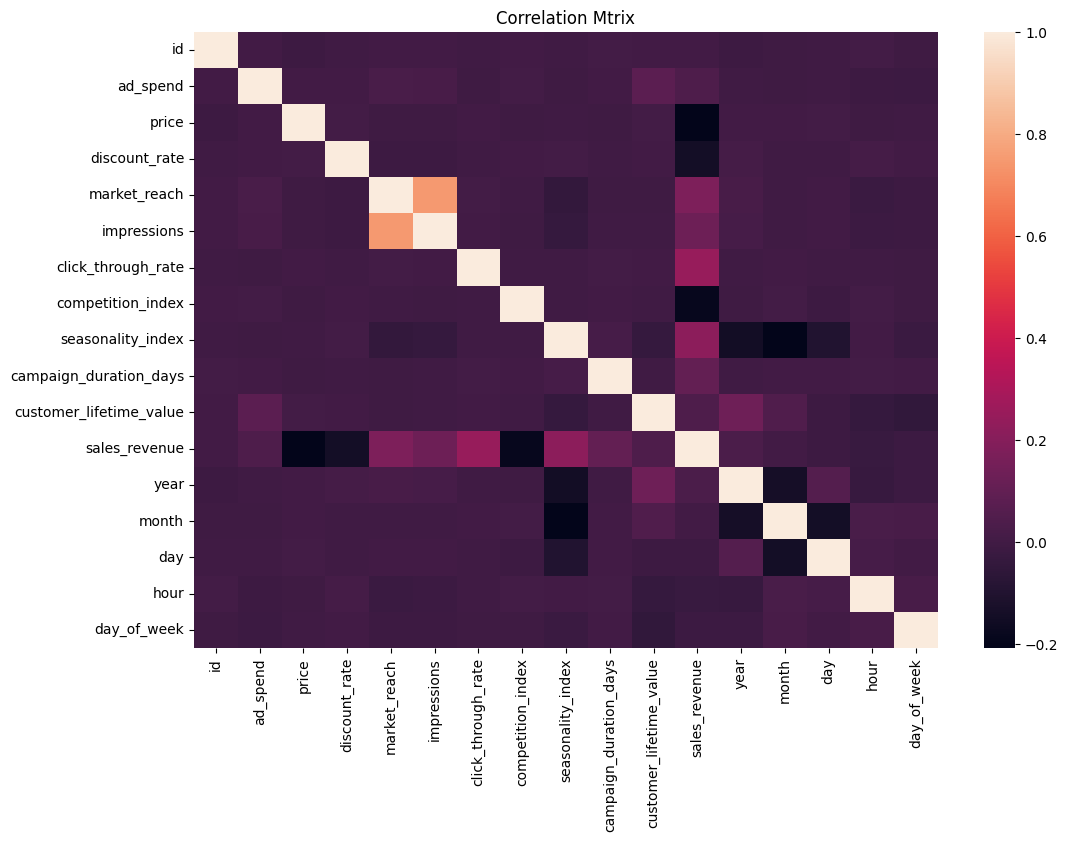

In [128]:
corr=df.corr(numeric_only=True)
plt.figure(figsize=(12,8))
sns.heatmap(corr,annot=False)
plt.title("Correlation Mtrix")
plt.show()


In [129]:
#The heatmap shows that click-through rate, seasonality index, and market reach 
#positively influence revenue, while price and competition negatively impact it.
#Other features show weak or no significant relationship.”

In [130]:
# sales revenue
corr["sales_revenue"].sort_values(ascending=False)

sales_revenue              1.000000
click_through_rate         0.246271
seasonality_index          0.221127
market_reach               0.178859
impressions                0.128222
campaign_duration_days     0.102231
customer_lifetime_value    0.042255
ad_spend                   0.040729
year                       0.029409
month                      0.003006
id                         0.002889
day                       -0.011629
day_of_week               -0.016852
hour                      -0.025830
discount_rate             -0.144324
competition_index         -0.188321
price                     -0.205893
Name: sales_revenue, dtype: float64

In [131]:
#“Click-through rate, seasonality index, and market reach are the strongest positive
#drivers of sales revenue, indicating that customer engagement and timing play a crucial 
#role. Price and competition index show negative relationships with revenue,
#suggesting that higher pricing and competitive pressure reduce sales. 
#Interestingly, ad spend has a very weak correlation with revenue, implying that 
#increased spending alone does not guarantee better performance.”

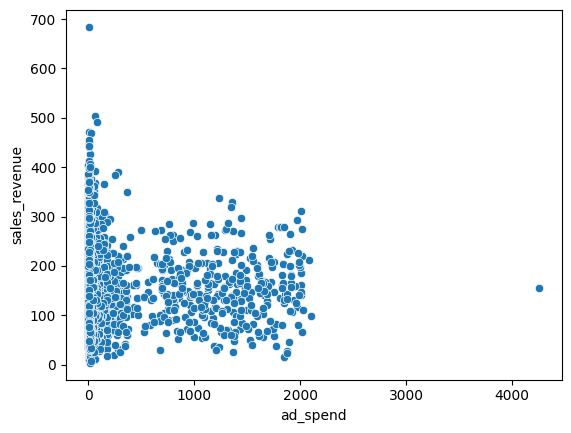

In [132]:
sns.scatterplot(x=df['ad_spend'], y=df['sales_revenue'])
plt.show()

In [133]:
#“Ad spend shows a weak to moderate positive relationship with revenue, but the relationship is noisy and inconsistent.”

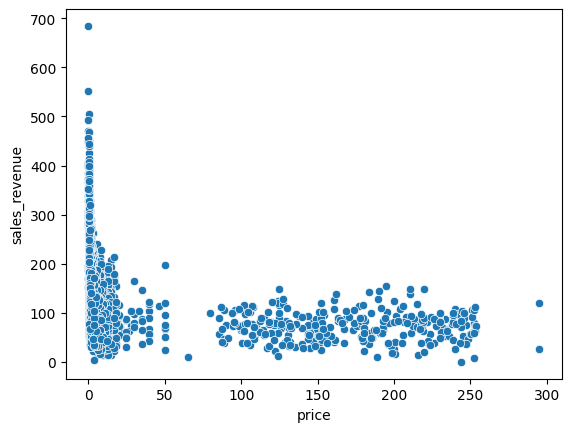

In [134]:
sns.scatterplot(x=df['price'], y=df['sales_revenue'])
plt.show()

In [135]:
# “Price shows very weak or almost no relationship with sales revenue.”

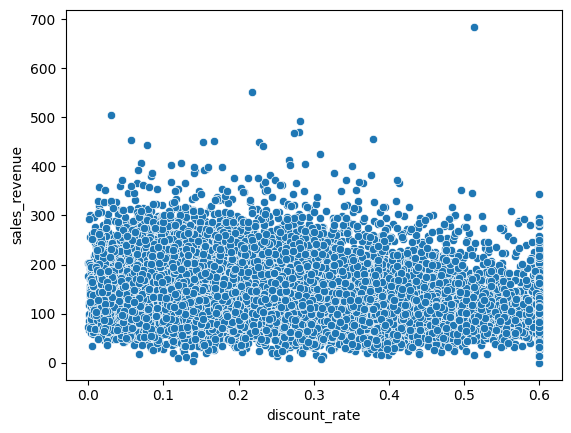

In [136]:
sns.scatterplot(x=df['discount_rate'], y=df['sales_revenue'])
plt.show()

In [137]:
# “Discount rate shows a weak relationship with revenue.”

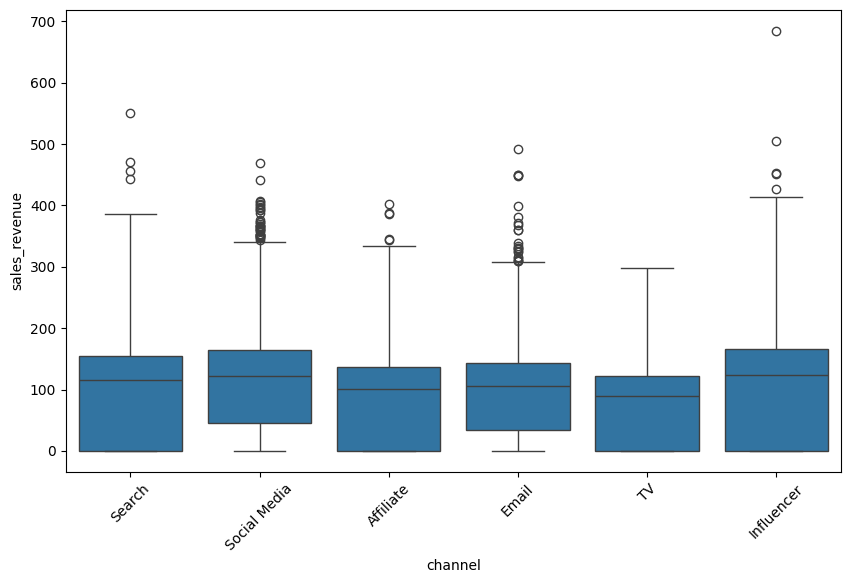

In [163]:
plt.figure(figsize=(10,6))
sns.boxplot(x='channel', y='sales_revenue', data=df)
plt.xticks(rotation=45)
plt.show()

In [139]:
#“Among all marketing channels, Influencer marketing generates the highest median revenue
#but with high variability and several extreme outliers, indicating potential for high
#but inconsistent returns. Social Media and Email also perform well with relatively\
# high median revenues. In contrast, TV shows the lowest median revenue with more 
#consistent but lower performance.”

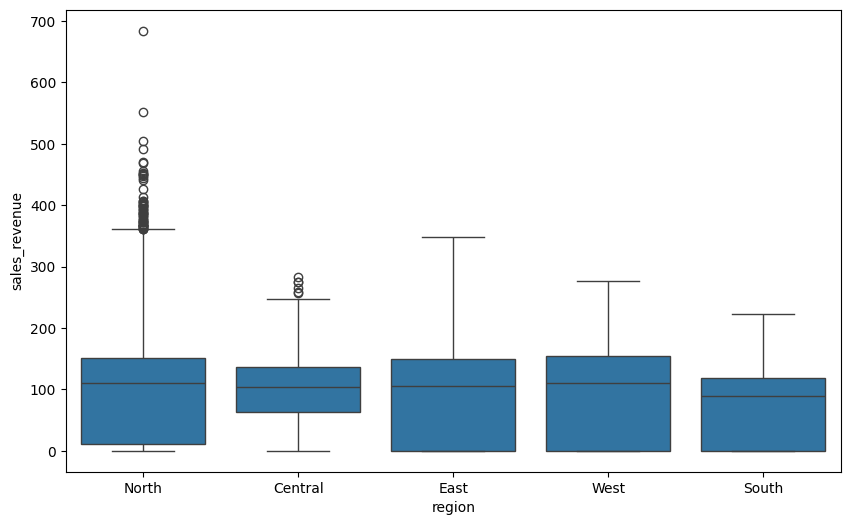

In [164]:
plt.figure(figsize=(10,6))
sns.boxplot(x="region",y="sales_revenue",data=df)
#plt.xticks(rotation=45)
plt.show()

In [141]:
#“The West region exhibits the highest median revenue, while the South region shows
#the lowest. North, Central, and East regions have similar revenue distributions.
#The North region demonstrates high variability with several extreme outliers, whereas
#the South region is more consistent but generates lower revenue overall.”

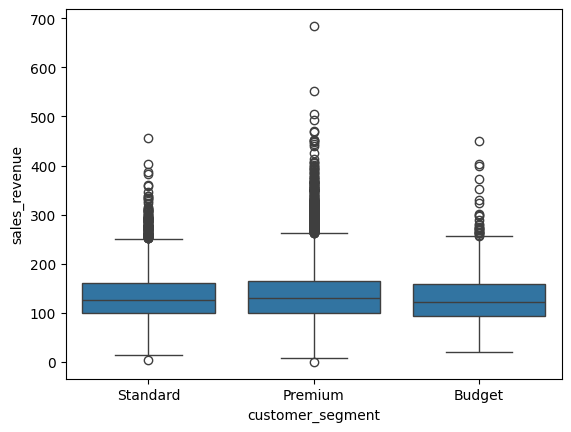

In [142]:
sns.boxplot(x="customer_segment",y="sales_revenue",data=df)
plt.show()

In [143]:
#“The Premium customer segment generates the highest median revenue with significant
#variability and high-value outliers, indicating strong but inconsistent performance.
#Standard and Budget segments have lower and relatively similar median revenues,
#with Budget customers showing more consistent but lower spending behavior.”

# time series analysis

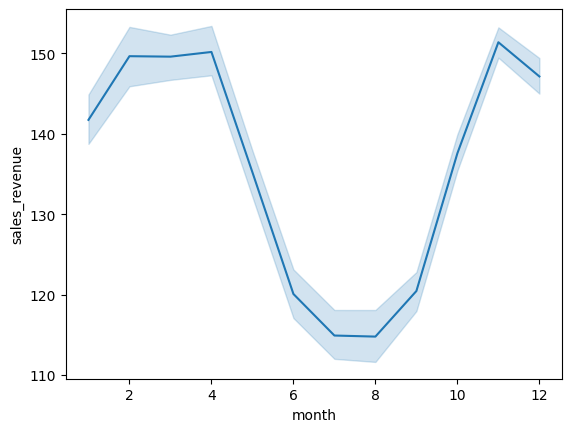

In [144]:
sns.lineplot(x='month', y='sales_revenue', data=df)
plt.show()

In [145]:
#“Sales revenue exhibits a clear seasonal pattern, with peaks observed during March–April
#and November, and a noticeable decline during July–August. This indicates strong
#seasonality in customer demand, likely influenced by market cycles or promotional
#periods.”

In [146]:
df["channel"].unique()

array(['Search', 'Social Media', 'Affiliate', 'Email', 'TV', 'Influencer',
       'Social_Media', 'Socail Media', 'social Media', 'SocialMedia',
       'social media'], dtype=object)

In [147]:
df["channel"]=df["channel"].str.lower().str.strip()

In [148]:
df['channel'] = df['channel'].replace({
    'social media': 'social media',
    'social_media': 'social media',
    'socail media': 'social media',
    'socialmedia': 'social media',
})

In [149]:
df['channel'] = df['channel'].replace({
    'search': 'Search',
    'social media': 'Social Media',
    'affiliate': 'Affiliate',
    'email': 'Email',
    'tv': 'TV',
    'influencer': 'Influencer'
})

In [150]:
df["region"]=df["region"].str.lower().str.strip()

In [151]:
df["region"].unique()

array(['nort', 'north', 'central', 'norht', 'east', 'west', 'south'],
      dtype=object)

In [152]:
df["region"]=df["region"].replace({"nort":"north",
                                   "north":"north",
                                  "norht":"north"})

In [153]:
df['region'] = df['region'].str.title()

In [154]:
#outliers
def cap_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])
    
    return df

In [155]:
df = cap_outliers(df, 'ad_spend')
df = cap_outliers(df, 'customer_lifetime_value')

In [156]:
df = df.fillna(0)

In [157]:
df.isna().sum()

id                         0
region                     0
channel                    0
product_category           0
customer_segment           0
ad_spend                   0
price                      0
discount_rate              0
market_reach               0
impressions                0
click_through_rate         0
competition_index          0
seasonality_index          0
campaign_duration_days     0
customer_lifetime_value    0
sales_revenue              0
year                       0
month                      0
day                        0
hour                       0
day_of_week                0
dtype: int64

In [158]:
df['ad_spend'].describe()


count    24000.000000
mean        14.247238
std         12.450782
min          0.000000
25%          4.150000
50%         10.900000
75%         19.800000
max         42.075000
Name: ad_spend, dtype: float64

In [159]:
df['customer_lifetime_value'].describe()

count    24000.000000
mean      3607.941512
std       4262.980013
min          0.000000
25%        470.862500
50%       1624.935000
75%       5176.907500
max      12778.056250
Name: customer_lifetime_value, dtype: float64

In [160]:
# keep copy before capping
df_before = df.copy()

# apply capping
df = cap_outliers(df, 'ad_spend')

# check changes
print("Values capped in ad_spend:",
      (df_before['ad_spend'] != df['ad_spend']).sum())

Values capped in ad_spend: 0


In [161]:
# keep copy before capping
df_before = df.copy()

# apply capping
df = cap_outliers(df,'customer_lifetime_value' )

# check changes
print("Values capped in ad_spend:",
      (df_before['customer_lifetime_value'] != df['customer_lifetime_value']).sum())

Values capped in ad_spend: 2958


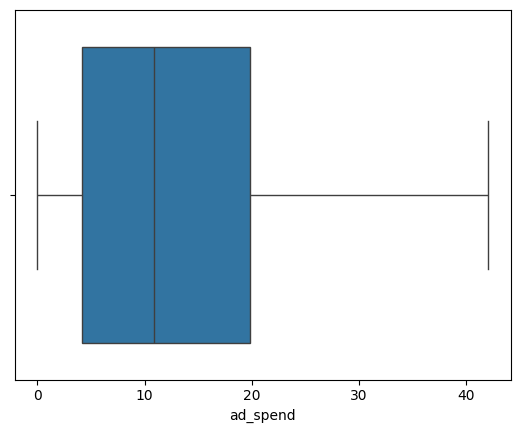

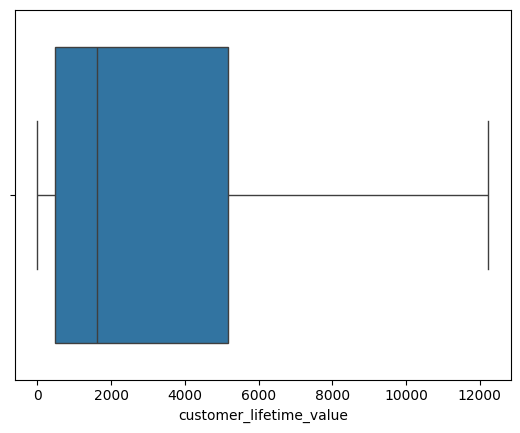

In [162]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['ad_spend'])
plt.show()

sns.boxplot(x=df['customer_lifetime_value'])
plt.show()

# ml part

### encoding

In [165]:
df = pd.get_dummies(df, drop_first=True)

In [166]:
df.shape

(24000, 33)

In [167]:
df = df[df['sales_revenue'].notna()]

In [168]:
df.shape

(24000, 33)

# split Features and target

In [169]:
X=df.drop("sales_revenue",axis=1)
y=df["sales_revenue"]

In [170]:
#removing constant columns
const_cols = [col for col in X.columns if X[col].nunique() == 1]
print(const_cols)

[]


In [97]:
# print(X_train.isnull().sum().sum())

In [ ]:
# X_train = X_train.fillna(X_train.median())

In [ ]:
# X_test = X_test.fillna(X_train.median())

In [ ]:
# print(X_train.isnull().sum().sum())
# print(X_test.isnull().sum().sum())

# train test split

In [171]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [172]:
print(X_train.shape)
print(X_test.shape)

(19200, 32)
(4800, 32)


# Scaling

In [173]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
# fit only on training data
X_train_scaled=scaler.fit_transform(X_train)
# Transform test data
X_test_scaled=scaler.transform(X_test)

In [174]:
print(X_train_scaled[:5])

[[-1.21623226  0.44901009  0.19766416 -1.13964589 -0.68753224 -0.44284063
  -0.84654497 -1.50341234  0.41103373 -0.17367801 -0.75950144  1.03223799
   1.01619198  0.2160229  -0.90684289  0.17609148 -0.14808407  0.1871909
  -0.04511523 -0.06746759 -0.49894183 -0.334297   -0.50585272  1.75299005
  -0.33861324 -0.24735376 -0.22279853 -0.3426127  -0.29955413 -0.51630835
  -2.00653383  2.33672765]
 [ 0.69153588  1.25740264 -0.19688268  0.95459312 -0.86106513 -0.77257453
  -0.84250904  0.88348057 -0.3837036  -0.17367801 -0.53167752 -0.7366811
   0.72564821  1.48395601 -1.26177161  0.17609148 -0.14808407  0.1871909
  -0.04511523 -0.06746759  2.00424165 -0.334297   -0.50585272 -0.57045389
  -0.33861324 -0.24735376 -0.22279853 -0.3426127  -0.29955413 -0.51630835
   0.49837186 -0.42794889]
 [ 1.23469378 -0.34657623 -0.21592977 -0.67860073 -0.54224889 -0.66761143
  -0.59833551  0.63672425 -0.3837036  -0.17367801 -0.32153817  1.03223799
  -0.72707066  1.59922266 -0.55191417  1.7040923  -0.14808407

In [175]:
X_train_scaled.mean(axis=0)

array([ 1.55431223e-17, -3.55271368e-17, -3.25665421e-17,  9.93649607e-17,
       -6.14323407e-17,  8.88178420e-18,  5.25505565e-17, -1.00752739e-16,
        4.99600361e-18,  7.25345709e-17,  5.84717460e-17, -5.90372196e-14,
       -1.11022302e-16,  1.00475184e-16,  1.05748743e-16, -3.25665421e-17,
        3.33066907e-18, -2.36107430e-16, -7.40148683e-18,  5.32907052e-17,
       -1.27675648e-17, -4.29286236e-17,  5.32907052e-17, -2.72004641e-17,
       -3.20114305e-17, -4.99600361e-18, -1.85037171e-17,  3.40468394e-17,
        7.75305746e-17,  8.84477676e-17, -2.07241631e-17,  2.59052039e-18])

In [176]:
X_train_scaled.std(axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

# basic model

In [177]:
from sklearn.neighbors import KNeighborsRegressor
knn=KNeighborsRegressor(n_neighbors=5,weights="distance")
knn.fit(X_train_scaled,y_train)

,n_neighbors,5
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


# prediction

In [178]:
y_pred = np.where(y_pred < 20, 0, y_pred)

In [179]:
y_pred=knn.predict(X_test_scaled)

In [180]:
print("Actual:", y_test.values[:10])
print("Predicted:", y_pred[:10])

Actual: [ 35.28880919   0.         100.33202308   0.           0.
 151.02437019 112.17203999 101.91582158 129.68971324   0.        ]
Predicted: [ 58.29536797  31.80621271  46.35800769  47.55338942  34.6813364
 167.62481673 116.88977141 155.06201767 130.63909438  34.52506523]


# evaluate the model

In [181]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
#import numpy as np
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print("MAE:",mae)
print("MSE:",mse)
print("RMSE:",rmse)
print("R2 Score:",r2)

MAE: 50.70551764941117
MSE: 4370.731203123725
RMSE: 66.11150583010287
R2 Score: 0.26620283444602055


# trying multiple k values

In [182]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score
for k in range(1,21):
    knn=KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled,y_train)
    y_pred=knn.predict(X_test_scaled)
    r2=r2_score(y_test,y_pred)
    print(f"k={k},r2={r2}")
    

k=1,r2=-0.28665603694207586
k=2,r2=0.07577915650423539
k=3,r2=0.18712981531969475
k=4,r2=0.2355966167107294
k=5,r2=0.26355872285790183
k=6,r2=0.2889210854091556
k=7,r2=0.3029283902961919
k=8,r2=0.3107380002663196
k=9,r2=0.31741456026366366
k=10,r2=0.32172711688961697
k=11,r2=0.3223810313081086
k=12,r2=0.3271584541285135
k=13,r2=0.32793986285718624
k=14,r2=0.33033893543706494
k=15,r2=0.3292854652257
k=16,r2=0.3305022490684021
k=17,r2=0.33272300590873083
k=18,r2=0.33507692384657917
k=19,r2=0.33445472800832565
k=20,r2=0.33630676311747365


# final model

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
knn=KNeighborsRegressor(n_neighbors=20,weights="distance",p=1)
knn.fit(X_train_scaled,y_train)
y_pred=knn.predict(X_test_scaled)

# evaluate model

In [95]:
from sklearn.metrics import r2_score
print("Final R2:",r2_score(y_test,y_pred))

Final R2: 0.39345156456725905


# save model +scaler

In [96]:
import pickle

# Save model
pickle.dump(knn, open('knn_model.pkl', 'wb'))

# Save scaler
pickle.dump(scaler, open('scaler.pkl', 'wb'))

# Save feature columns (CRITICAL for 32 features)
pickle.dump(X.columns, open('columns.pkl', 'wb'))